# RLA-WM Colab demo (PushT)

Two sections:
1. Load the released PushT RLA-WM and run a single t→t+h flow rollout.
2. Train PushT WMRL for 50 iterations on a T4 (seed 1).

Runtime: select **GPU (T4)** under *Runtime → Change runtime type*. Total runtime ≈ 2 hour.


## Setup

Note you must setup your HF_TOKEN from https://huggingface.co/settings/tokens (with dinov3 access granted from https://huggingface.co/facebook/dinov3-vitl16-pretrain-lvd1689m) in your colab secrets! Otherwise the huggingface will not be able to access dinov3 model!

![image.png](https://i.imgur.com/UNGBfWp.png)

In [1]:
from google.colab import userdata
userdata.get('HF_TOKEN')
print("HF_TOKEN is set.")

HF_TOKEN is set.


In [2]:
import os, sys, subprocess, pathlib

REPO_URL  = "https://github.com/mlzxy/rla-wm.git"
REPO_PATH = "/content/rla-wm"

if not pathlib.Path(REPO_PATH, "train.py").exists():
    subprocess.run(["git", "clone", "--depth=1", REPO_URL, REPO_PATH], check=True)

os.chdir(REPO_PATH)
sys.path[:0] = [REPO_PATH, os.path.join(REPO_PATH, "third_party", "diffusion_policy")]
print("cwd:", os.getcwd())


cwd: /content/rla-wm


In [3]:
%pip install -q --upgrade pip
%pip install -q \
    "mani-skill==3.0.0b22" \
    "open-clip-torch>=3.2.0" "transformers>=4.57.3" "diffusers>=0.21.4" \
    "huggingface-hub>=0.36.0" \
    "omegaconf>=2.3.0" "easydict" "ruamel-yaml>=0.18.16" "h5py>=3.15.1" \
    "imageio>=2.37.2" "imageio-ffmpeg>=0.6.0" "opencv-python-headless>=4.12.0.88" \
    "peft>=0.19.0" "roma>=1.5.4" "scipy>=1.15.3" "tensorboard>=2.20.0" \
    "rich" "tyro" "tqdm" "pandas" "wandb" "decord" "jaxtyping" "jstyleson" "redis" "lpips" \
    "git+https://github.com/EasternJournalist/utils3d" "zarr"

%pip uninstall -q -y "torchao"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 28.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.


In [4]:
from huggingface_hub import snapshot_download, hf_hub_download

# if your HF_TOKEN is not set correctly, this will fail!
snapshot_download(
    repo_id="facebook/dinov3-vitl16-pretrain-lvd1689m",
    repo_type="model"
)

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

'/root/.cache/huggingface/hub/models--facebook--dinov3-vitl16-pretrain-lvd1689m/snapshots/ea8dc2863c51be0a264bab82070e3e8836b02d51'

In [5]:

snapshot_download(
    repo_id="xyzhang368/RLA-WM",
    repo_type="model",
    allow_patterns=[
        "rla/maniskill/**",
        "rla-wm/maniskill/ur10e/**",
        "dino-to-image_unet/maniskill/**",
        "wmrl_checkpoints/0_bc_s2r_nstate/**",
    ],
    local_dir="runs/weights",
)
print("weights ready:", sorted(os.listdir("runs/weights")))


Fetching ... files: 0it [00:00, ?it/s]

weights ready: ['.cache', 'dino-to-image_unet', 'rla', 'rla-wm', 'wmrl_checkpoints']


In [6]:
import tarfile

tar_path = hf_hub_download(
    repo_id="xyzhang368/RLA-WM",
    repo_type="dataset",
    filename="maniskill_pusht.tar",
    local_dir="data",
)

with tarfile.open(tar_path) as t:
    t.extractall(path="data")

os.remove(tar_path)
n_traj = len(os.listdir("data/maniskill/ppo/ur10e_stick/PushT-v2/success"))
print(f"PushT trajectories ready: {n_traj}")


maniskill_pusht.tar:   0%|          | 0.00/203M [00:00<?, ?B/s]

/tmp/ipykernel_1762/2688666990.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall(path="data")


PushT trajectories ready: 1002


## §1 — RLA-WM inference (t → t+h)

Loads the released RLA-WM for the **UR10e-stick / PushT** combo, picks one successful trajectory, and predicts the future frame at horizon `h` from the current frame conditioned on the trajectory's `target_qpos`.


In [7]:
import os, sys
import torch
import numpy as np
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

from utils.misc import load_config
import src.models as models
import src.datasets as datasets
from src.trainers.rla_wm_trainer import RLAWMTrainer
from src.utils.loss_utils import ssim as compute_ssim, lpips as compute_lpips

RLA_WORKDIR      = "runs/weights/rla/maniskill/20260323_21-41-25"
RLAWM_CONFIG     = "configs/rla_wm/ur10e.yaml"
RLAWM_WORKDIR    = "runs/weights/rla-wm/maniskill/ur10e/20260404_15-49-19"
IMG_DECODER_CKPT = "runs/weights/dino-to-image_unet/maniskill/20260404_22-53-36"

DEVICE      = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
EULER_STEPS = 30
ROBOT_ID    = 2     # 0=panda, 1=xarm, 2=ur10e_stick
TASK_IND    = 0     # 0=PushT-v2 (per src/datasets/trajectory_dataset.py TASKS)
HORIZON     = 15

rlawm_cfg = load_config(RLAWM_CONFIG)

rlawm_models = {
    name: getattr(models, m["name"])(**m["args"]).to(DEVICE)
    for name, m in rlawm_cfg["models"].items()
}
trainer_kw = dict(rlawm_cfg["trainer"]["args"])
trainer_kw.pop("load_dir", None)
trainer_kw["batch_size"]              = 1
trainer_kw["num_workers"]             = 0
trainer_kw["skip_initial_snapshot"]   = True
trainer_kw["image_decoder_ckpt"]      = IMG_DECODER_CKPT
trainer_kw["encoder_ckpt"]            = RLA_WORKDIR

rlawm_trainer = RLAWMTrainer(
    rlawm_models, None,
    output_dir=RLAWM_WORKDIR, load_dir=RLAWM_WORKDIR, step=None,
    inference_only=True, **trainer_kw,
)
for m in rlawm_trainer.models.values():
    m.eval()
print("loaded:", list(rlawm_trainer.models))


/usr/local/lib/python3.12/dist-packages/sapien/_vulkan_tricks.py:42: UserWarning: Failed to find system libvulkan. Fallback to SAPIEN builtin libvulkan.
  warn("Failed to find system libvulkan. Fallback to SAPIEN builtin libvulkan.")
/usr/local/lib/python3.12/dist-packages/sapien/_vulkan_tricks.py:78: UserWarning: Failed to find Vulkan ICD file. This is probably due to an incorrect or partial installation of the NVIDIA driver. SAPIEN will attempt to provide an ICD file anyway but it may not work.
  warn(
/usr/local/lib/python3.12/dist-packages/sapien/_vulkan_tricks.py:100: UserWarning: Failed to find glvnd ICD file. This is probably due to an incorrect or partial installation of the NVIDIA driver. SAPIEN will attempt to provide an ICD file anyway but it may not work.
  warn(
2026-05-10 11:14:42,304 - mani_skill  - WARNING - Overriding registered agent panda
2026-05-10 11:14:42,305 - mani_skill  - WARNING - Overriding registered agent xarm6_robotiq
2026-05-10 11:14:42,572 - mani_skill  

Freezing model: encoder

Freezing model: decoder

Freezing model: image_decoder

Freezing model: flow_model

...

Loading decoder from runs/weights/rla/maniskill/20260323_21-41-25/ckpts/decoder_step0100000.pt

Decoder loaded successfully (strict)

Loading decoder from runs/weights/dino-to-image_unet/maniskill/20260404_22-53-36/ckpts/decoder_step0060000.pt

Image decoder loaded successfully (strict)

loaded: ['encoder', 'decoder', 'image_decoder', 'flow_model']


In [8]:
# Load a small dataset slice and pick the first successful PushT episode.
ds_args = dict(rlawm_cfg["dataset"]["args"])
ds_args["manual_limit"] = 64
ds_args["trajectory_info_cache_file"] = "runs/colab/cache/colab_demo_dataset.json"
dataset = datasets.TrajectoryDataset(**ds_args)

Building trajectory info (parallel x2): 100%|██████████| 990/990 [00:11<00:00, 88.50it/s] 


Saved trajectory_info to cache: runs/colab/cache/colab_demo_dataset.json

Dataset Summary:

play_ur10: 0 trajectories, 0 frames (0 interaction)

ppo_ur10: 990 trajectories, 53109 frames (34810 interaction)

└ data/maniskill/ppo/ur10e_stick/PushT-v2/success: 990 trajectories, 53109 frames (34810 interaction)

Total: 990 trajectories, 53109 frames

W0510 11:16:06.587000 1762 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/gymnasium/core.py:311: UserWarning: WARN: env.agent to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.agent` for environment variables or `env.get_wrapper_attr('agent')` that will search the reminding wrappers.
  logger.warn(


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:10<00:00, 50.9MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth


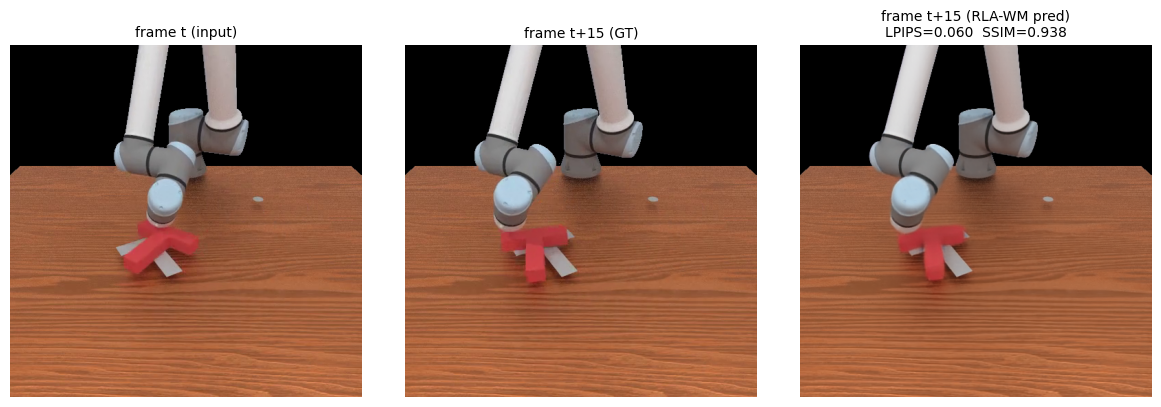

In [9]:
SAMPLE_SEED = 50
torch.manual_seed(SAMPLE_SEED); np.random.seed(SAMPLE_SEED)
sample = next(
    (dataset[i] for i in range(len(dataset))
     if bool(np.asarray(dataset[i]["success"]).reshape(-1)[0])),
    None,
)
if sample is None:
    raise RuntimeError("No successful PushT trajectory found in scan; raise manual_limit.")

rgbs   = torch.from_numpy(np.asarray(sample["rgbs"])).to(DEVICE)
masks  = torch.from_numpy(np.asarray(sample["foreground_masks"])).to(DEVICE)
masked = rgbs.float() * (masks > 0).float().unsqueeze(2) / 255.0   # (T, 1, 3, H, W) in [0,1]
target_qpos = torch.from_numpy(np.asarray(sample["target_qpos"])).to(DEVICE).float()

with torch.no_grad():
    wm_tokens, patch_hw = rlawm_trainer._extract_dino_tokens(masked[:, :1])
    x_t = wm_tokens[0].float()

    robot_ids = torch.tensor([ROBOT_ID], device=DEVICE)
    task_inds = torch.tensor([TASK_IND], device=DEVICE)
    horizons  = torch.tensor([HORIZON], device=DEVICE, dtype=torch.float)
    full_qpos = rlawm_trainer._target_qpos_to_full_qpos([target_qpos], robot_ids, task_inds)

    flow_model = rlawm_trainer.models["flow_model"]
    num_lat    = getattr(flow_model, "num_tokens", rlawm_trainer.models["encoder"].num_tokens)
    token_dim  = flow_model.token_dim

    gen   = torch.Generator(device=DEVICE).manual_seed(SAMPLE_SEED)
    noise = torch.randn(1, num_lat, token_dim, device=DEVICE, generator=gen)

    sampled = rlawm_trainer._euler_sample(
        flow_model=flow_model, noise=noise, xt_tokens=x_t,
        task_inds=task_inds, horizons=horizons, robot_ids=robot_ids,
        full_qpos_list=full_qpos, steps=EULER_STEPS,
    )
    pred_latent = rlawm_trainer._denormalize_latent_tokens(sampled, flow_model=flow_model)
    _, pred_x_T = rlawm_trainer.models["decoder"](x_t, tokens=pred_latent)
    pred_img    = rlawm_trainer.models["image_decoder"](
        pred_x_T.unsqueeze(1).contiguous(), patch_hw=patch_hw,
    )[:, 0].clamp(0, 1)

gt_t_pil    = TF.to_pil_image(masked[0, 0].clamp(0, 1).cpu())
gt_T_pil    = TF.to_pil_image(masked[1, 0].clamp(0, 1).cpu())
pred_T_pil  = TF.to_pil_image(pred_img[0].clamp(0, 1).cpu())

lpips_v = compute_lpips(pred_img, masked[1, :1]).item()
ssim_v  = compute_ssim(pred_img, masked[1, :1]).item()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, ttl in zip(
    axes,
    [gt_t_pil, gt_T_pil, pred_T_pil],
    ["frame t (input)", f"frame t+{HORIZON} (GT)",
     f"frame t+{HORIZON} (RLA-WM pred)\nLPIPS={lpips_v:.3f}  SSIM={ssim_v:.3f}"],
):
    ax.imshow(img); ax.set_title(ttl, fontsize=10); ax.axis("off")
plt.tight_layout(); plt.show()


In [10]:
import gc
del rlawm_trainer, rlawm_models, flow_model, sampled, pred_latent, pred_x_T, pred_img, wm_tokens
gc.collect()
torch.cuda.empty_cache()
if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()
    print(f"free GPU memory: {free / 1e9:.1f} / {total / 1e9:.1f} GB")


free GPU memory: 14.6 / 15.6 GB


## §2 — WMRL training

Hyperparameters tuned for a free-tier T4 (16 GB):

- `num_envs=32`, `env_batch_num=4` → world-model forward pass runs as 4 sequential chunks of 8 envs each (single-process; `MultiProcessWorldModelVecEnv` only triggers on multi-GPU).
- `num_steps=4`, `mini_batch_size=64`, `update_epochs=4` → 32×4/64 = 2 SGD steps per epoch, ×4 epochs = 8 updates per rollout.
- `total_iterations=50`, `eval_freq=25`, `run_initial_eval=True` → evals at iters 0, 25, and 49 (the final-iter override at [wmrl/train.py:505](../wmrl/train.py#L505) lands the third eval one iter early; we label it "iter 50" in the plot for readability).

In [11]:
import dataclasses
from utils.misc import load_config
from wmrl.train import Args

yaml_cfg     = load_config("wmrl/configs/pusht.yaml")
field_names  = {f.name for f in dataclasses.fields(Args)}
args         = Args(**{k: v for k, v in yaml_cfg.items() if k in field_names})
args.config_file = "wmrl/configs/pusht.yaml"

# T4 sizing
args.num_envs        = 32
args.env_batch_num   = 4    # 4 x 8-env, for T4 GPU at colab
args.num_steps       = 4
args.mini_batch_size = 64
args.update_epochs   = 4     # 32*4/64*4 -> 8 updates per rollout
args.bc_loss_weight  = 0.0
args.use_critic      = True

# Run shape
args.seed              = 1
args.total_iterations  = 50  # just 10x8 updates, for a quick demo
args.eval_freq         = 25
args.run_initial_eval  = False
args.save_freq         = 25
args.eval_num_episodes = 50

# Wiring
args.run_dir   = "runs/colab"
args.tag       = f"pusht-corr-seed{args.seed}"
args.use_wandb = False
args.use_tb    = False
args.policy_kwargs["enable_rl_lora"] = True
args.env_kwargs["reward_mode"] = "corresponding"
args.env_kwargs["terminal_success_bonus"] = 0.0

print(f"run_dir = {args.run_dir}/{args.tag}-...")


run_dir = runs/colab/pusht-corr-seed1-...


In [12]:
from wmrl.train import train
success_rates = train(args)

    1 run_id: 0                                                                                                    
    2 tag: pusht-corr-seed1                                                                                        
    3 env_cls: wmrl.world_model_env.FlowWorldModelVecEnv                                                           
    4 agent_cls: wmrl.agent_critic.WMRLAgentWithCritic                                                             
    5 env_kwargs:                                                                                                  
    6   dataset_dir: data/maniskill/ppo/ur10e_stick/PushT-v2/success                                               
    7   cameras:                                                                                                   
    8   - front_lower_camera                                                                                       
    9   img_size: 512                                                                                              
   10   use_foreground_mask: true                                                                                  
   11   flow_model_work_dir: runs/weights/rla-wm/maniskill/ur10e/20260404_15-49-19                                 
   12   image_decoder_work_dir: runs/weights/dino-to-image_unet/maniskill/20260404_22-53-36                        
   13   encoder_work_dir: runs/weights/rla/maniskill/20260323_21-41-25                                             
   14   p_initial_frame: 0.5                                                                                       
   15   max_chunk_steps: 6                                                                                         
   16   euler_steps: 30                                                                                            
   17   robot_uid: ur10e_stick                                                                                     
   18   control_mode: pd_joint_pos                                                                                 
   19   task_ind: 0                                                                                                
   20   reward_token_metric: l1                                                                                    
   21   success_token_threshold: 0.032                                                                             
   22   terminal_success_bonus: 0.0                                                                                
   23   dino_channels: 1024                                                                                        
   24   reward_mode: corresponding                                                                                 
   25 agent_kwargs: {}                                                                                             
   26 seed: 1                                                                                                      
   27 resume_ckpt: null                                                                                            
   28 task: PushT-v2                                                                                               
   29 robot: ur10e_stick                                                                                           
   30 control_mode: pd_joint_pos                                                                                   
   31 num_envs: 32                                                                                                 
   32 env_batch_num: 4                                                                                             
   33 total_iterations: 50                                                                                         
   34 total_timesteps: 2000000                                                                                     
   35 num_steps: 4                                      

2026-05-10 11:16:49,201 - mani_skill  - WARNING - ur10e_stick is not in the task's list of supported robots. Code may not run as intended


Loading DINOv3 model: facebook/dinov3-vitl16-pretrain-lvd1689m...


Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

Loading decoder from runs/weights/dino-to-image_unet/maniskill/20260404_22-53-36/ckpts/decoder_step0060000.pt

...

flow fwd (env_batch_num=4):   0%|          | 0/4 [00:00<?, ?it/s]

[blue]Running evaluation at iteration 49...[/blue]


Eval:   0%|          | 0/5000 [00:00<?, ?it/s]

[13:15:06] iter=49  eval: {'success_rate': 0.26, 'avg_reward': 18.462522597797214}


[13:15:06] Saved final checkpoint to runs/colab/pusht-pusht-corr-seed1-run0/1778411809/final.pt

In [13]:
# pre-computed success rates on colab gpu T4, so we skip one slow eval
# note that this differs a little bit on each GPU
# on A6000 / T4 -> 16%
# on A4500 ada -> 20%
# on A6000 ada -> 22%
# I believe the reason is I use ray-tracing for data collection and evaluation
# but some gpu does not natively support ray-tracing well and only have software fallback, this causes some performance diff/drop.
init_sr  = 0.16 if not args.run_initial_eval else success_rates[0]

after_sr = max(success_rates if not args.run_initial_eval else success_rates[1:])
print(f"initial SR  : {init_sr:.3f}")
print(f"After SR    : {after_sr:.3f}")

initial SR  : 0.160
After SR    : 0.260
